<a href="https://colab.research.google.com/github/Hiraeth-mist/aging-muscle-transcriptomics-case-study/blob/main/notebooks/01_data_import_qc.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Import and Quality Assessment

This notebook performs the initial processing and quality assessment of Salmon transcript quantification files from GEO dataset GSE287832.

Objectives:

- Import transcript quantifications
- Generate gene-level counts
- Create DESeq2 dataset
- Assess sample clustering
- Visualize transcriptomic variation using PCA

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
install.packages("BiocManager")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [4]:
BiocManager::install(c(
    "tximport",
    "DESeq2",
    "AnnotationDbi",
    "ensembldb",
    "EnsDb.Mmusculus.v79",
    "pheatmap"
))

'getOption("repos")' replaces Bioconductor standard repositories, see
'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://cran.rstudio.com

Bioconductor version 3.23 (BiocManager 1.30.27), R 4.6.0 (2026-04-24)

Installing package(s) 'BiocVersion', 'tximport', 'DESeq2', 'AnnotationDbi',
  'ensembldb', 'EnsDb.Mmusculus.v79', 'pheatmap'

also installing the dependencies ‘formatR’, ‘abind’, ‘SparseArray’, ‘lambda.r’, ‘futile.options’, ‘cigarillo’, ‘RCurl’, ‘rjson’, ‘S4Arrays’, ‘DelayedArray’, ‘futile.logger’, ‘snow’, ‘BH’, ‘png’, ‘XVector’, ‘lazyeval’, ‘UCSC.utils’, ‘XML’, ‘GenomicAlignments’, ‘BiocIO’, ‘restfulr’, ‘bitops’, ‘Rhtslib’, ‘S4Vectors’, ‘IRanges’, ‘GenomicRanges’, ‘SummarizedExperiment’, ‘BiocGenerics’, ‘Biobase’, ‘BiocParallel’, ‘matrixStats’, ‘locfit’, ‘MatrixGenerics’, ‘RcppArmadillo’, ‘RSQLite’, ‘KEGGREST’, ‘GenomicFeatures’, ‘AnnotationFilter’, ‘Seqinfo’, ‘GenomeInfoDb’, ‘rtracklayer’, ‘Rsamtools’, ‘ProtGenerics’, ‘Biost

In [5]:
library(tximport)
library(DESeq2)
library(ensembldb)
library(EnsDb.Mmusculus.v79)
library(pheatmap)

sessionInfo()

Loading required package: S4Vectors

Loading required package: stats4

Loading required package: BiocGenerics

Loading required package: generics


Attaching package: ‘generics’


The following objects are masked from ‘package:base’:

    as.difftime, as.factor, as.ordered, intersect, is.element, setdiff,
    setequal, union



Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, is.unsorted, lapply, Map, mapply, match, mget,
    order, paste, pmax, pmax.int, pmin, pmin.int, Position, rank,
    rbind, Reduce, rownames, sapply, saveRDS, table, tapply, unique,
    unsplit, which.max, which.min



Attaching package: ‘S4Vectors’


The following object is masked from ‘package:utils’:

    findMatches


The follo

R version 4.6.0 (2026-04-24)
Platform: x86_64-pc-linux-gnu
Running under: Ubuntu 22.04.5 LTS

Matrix products: default
BLAS:   /usr/lib/x86_64-linux-gnu/openblas-pthread/libblas.so.3 
LAPACK: /usr/lib/x86_64-linux-gnu/openblas-pthread/libopenblasp-r0.3.20.so;  LAPACK version 3.10.0

locale:
 [1] LC_CTYPE=en_US.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=en_US.UTF-8        LC_COLLATE=en_US.UTF-8    
 [5] LC_MONETARY=en_US.UTF-8    LC_MESSAGES=en_US.UTF-8   
 [7] LC_PAPER=en_US.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=en_US.UTF-8 LC_IDENTIFICATION=C       

time zone: Etc/UTC
tzcode source: system (glibc)

attached base packages:
[1] stats4    stats     graphics  grDevices utils     datasets  methods  
[8] base     

other attached packages:
 [1] pheatmap_1.0.13             EnsDb.Mmusculus.v79_2.99.0 
 [3] ensembldb_2.36.1            AnnotationFilter_1.36.0    
 [5] GenomicFeatures_1.64.0      Annotation

In [6]:
data_dir <- "/content/drive/MyDrive/aging-muscle-transcriptomics-case-study/data/raw"

list.files(data_dir)

[1] "GSM8752128_ey1.AGCCAAGGAC-AGGTGTCCTC.quant.sf.gz"
 [2] "GSM8752130_eo1.AACCATACCG-CTTCTGTGCG.quant.sf.gz"
 [3] "GSM8752132_eo2.CCTAGTGGAC-TGGCTCATGT.quant.sf.gz"
 [4] "GSM8752133_eo3.CACTATTCCA-TATAGGCCGA.quant.sf.gz"
 [5] "GSM8752135_ey2.CGTAGATCGC-ATACGTCTCT.quant.sf.gz"
 [6] "GSM8752137_ey3.TCCTACGTGC-GCATTCTCGC.quant.sf.gz"
 [7] "GSM8752139_so1.AAGGACCGCA-ATGAGAGAGA.quant.sf.gz"
 [8] "GSM8752141_so2.GTACCGGATA-AGTGAAGCGC.quant.sf.gz"
 [9] "GSM8752142_so3.AGCATGCTGT-ACACAATCCA.quant.sf.gz"
[10] "GSM8752144_sy1.TCGTTAGATC-ACCAATTCGG.quant.sf.gz"
[11] "GSM8752146_sy2.CACTCGCATA-GATACGACTT.quant.sf.gz"
[12] "GSM8752148_sy3.TCTCTAGCGC-CTGCTTGACG.quant.sf.gz"
[13] "GSM8752149_to1.AAGCTTCGAG-GATGTCATGC.quant.sf.gz"
[14] "GSM8752151_to2.TCGTGATCAG-ACACTACGTA.quant.sf.gz"
[15] "GSM8752153_to3.AGGAACAGCA-ATAACCGGCA.quant.sf.gz"
[16] "GSM8752155_ty1.CGCAGGAGTA-GCGACCTTGA.quant.sf.gz"
[17] "GSM8752156_ty2.CACACTGTTG-ATTCCACACT.quant.sf.gz"
[18] "GSM8752158_ty3.CAGACGATGA-GCATGCTGGA.quant.sf.gz"

In [7]:
metadata <- read.csv(
  "/content/drive/MyDrive/aging-muscle-transcriptomics-case-study/data/sample_metadata.csv"
)

metadata

sample_id,muscle,age
<chr>,<chr>,<chr>
ey1,EDL,Young
ey2,EDL,Young
ey3,EDL,Young
eo1,EDL,Old
eo2,EDL,Old
eo3,EDL,Old
sy1,Soleus,Young
sy2,Soleus,Young
sy3,Soleus,Young


In [8]:
data_dir <- "/content/drive/MyDrive/aging-muscle-transcriptomics-case-study/data/raw"

files <- list.files(
  data_dir,
  pattern = "quant.sf.gz$",
  full.names = TRUE
)

length(files)

head(files)

[1] 18

[1] "/content/drive/MyDrive/aging-muscle-transcriptomics-case-study/data/raw/GSM8752128_ey1.AGCCAAGGAC-AGGTGTCCTC.quant.sf.gz"
[2] "/content/drive/MyDrive/aging-muscle-transcriptomics-case-study/data/raw/GSM8752130_eo1.AACCATACCG-CTTCTGTGCG.quant.sf.gz"
[3] "/content/drive/MyDrive/aging-muscle-transcriptomics-case-study/data/raw/GSM8752132_eo2.CCTAGTGGAC-TGGCTCATGT.quant.sf.gz"
[4] "/content/drive/MyDrive/aging-muscle-transcriptomics-case-study/data/raw/GSM8752133_eo3.CACTATTCCA-TATAGGCCGA.quant.sf.gz"
[5] "/content/drive/MyDrive/aging-muscle-transcriptomics-case-study/data/raw/GSM8752135_ey2.CGTAGATCGC-ATACGTCTCT.quant.sf.gz"
[6] "/content/drive/MyDrive/aging-muscle-transcriptomics-case-study/data/raw/GSM8752137_ey3.TCCTACGTGC-GCATTCTCGC.quant.sf.gz"

In [9]:
metadata <- read.csv(
  "/content/drive/MyDrive/aging-muscle-transcriptomics-case-study/data/sample_metadata.csv"
)

metadata

sample_id,muscle,age
<chr>,<chr>,<chr>
ey1,EDL,Young
ey2,EDL,Young
ey3,EDL,Young
eo1,EDL,Old
eo2,EDL,Old
eo3,EDL,Old
sy1,Soleus,Young
sy2,Soleus,Young
sy3,Soleus,Young


In [10]:
basename(files)

[1] "GSM8752128_ey1.AGCCAAGGAC-AGGTGTCCTC.quant.sf.gz"
 [2] "GSM8752130_eo1.AACCATACCG-CTTCTGTGCG.quant.sf.gz"
 [3] "GSM8752132_eo2.CCTAGTGGAC-TGGCTCATGT.quant.sf.gz"
 [4] "GSM8752133_eo3.CACTATTCCA-TATAGGCCGA.quant.sf.gz"
 [5] "GSM8752135_ey2.CGTAGATCGC-ATACGTCTCT.quant.sf.gz"
 [6] "GSM8752137_ey3.TCCTACGTGC-GCATTCTCGC.quant.sf.gz"
 [7] "GSM8752139_so1.AAGGACCGCA-ATGAGAGAGA.quant.sf.gz"
 [8] "GSM8752141_so2.GTACCGGATA-AGTGAAGCGC.quant.sf.gz"
 [9] "GSM8752142_so3.AGCATGCTGT-ACACAATCCA.quant.sf.gz"
[10] "GSM8752144_sy1.TCGTTAGATC-ACCAATTCGG.quant.sf.gz"
[11] "GSM8752146_sy2.CACTCGCATA-GATACGACTT.quant.sf.gz"
[12] "GSM8752148_sy3.TCTCTAGCGC-CTGCTTGACG.quant.sf.gz"
[13] "GSM8752149_to1.AAGCTTCGAG-GATGTCATGC.quant.sf.gz"
[14] "GSM8752151_to2.TCGTGATCAG-ACACTACGTA.quant.sf.gz"
[15] "GSM8752153_to3.AGGAACAGCA-ATAACCGGCA.quant.sf.gz"
[16] "GSM8752155_ty1.CGCAGGAGTA-GCGACCTTGA.quant.sf.gz"
[17] "GSM8752156_ty2.CACACTGTTG-ATTCCACACT.quant.sf.gz"
[18] "GSM8752158_ty3.CAGACGATGA-GCATGCTGGA.quant.sf.gz"

In [11]:
sample_ids <- sub(
  ".*_(ey|eo|sy|so|ty|to)([123]).*",
  "\\1\\2",
  basename(files)
)

sample_ids

[1] "ey1" "eo1" "eo2" "eo3" "ey2" "ey3" "so1" "so2" "so3" "sy1" "sy2" "sy3"
[13] "to1" "to2" "to3" "ty1" "ty2" "ty3"

In [12]:
names(files) <- sample_ids

files

ey1 
"/content/drive/MyDrive/aging-muscle-transcriptomics-case-study/data/raw/GSM8752128_ey1.AGCCAAGGAC-AGGTGTCCTC.quant.sf.gz" 
                                                                                                                       eo1 
"/content/drive/MyDrive/aging-muscle-transcriptomics-case-study/data/raw/GSM8752130_eo1.AACCATACCG-CTTCTGTGCG.quant.sf.gz" 
                                                                                                                       eo2 
"/content/drive/MyDrive/aging-muscle-transcriptomics-case-study/data/raw/GSM8752132_eo2.CCTAGTGGAC-TGGCTCATGT.quant.sf.gz" 
                                                                                                                       eo3 
"/content/drive/MyDrive/aging-muscle-transcriptomics-case-study/data/raw/GSM8752133_eo3.CACTATTCCA-TATAGGCCGA.quant.sf.gz" 
                                                                                                                       ey2 
"/content/drive/MyDrive/aging-muscle-transcriptomics-case-study/data/raw/GSM8752135_ey2.CGTAGATCGC-ATACGTCTCT.quant.sf.gz" 
                                                                                                                       ey3 
"/content/drive/MyDrive/aging-muscle-transcriptomics-case-study/data/raw/GSM8752137_ey3.TCCTACGTGC-GCATTCTCGC.quant.sf.gz" 
                                                                                                                       so1 
"/content/drive/MyDrive/aging-muscle-transcriptomics-case-study/data/raw/GSM8752139_so1.AAGGACCGCA-ATGAGAGAGA.quant.sf.gz" 
                                                                                                                       so2 
"/content/drive/MyDrive/aging-muscle-transcriptomics-case-study/data/raw/GSM8752141_so2.GTACCGGATA-AGTGAAGCGC.quant.sf.gz" 
                                                                                                                       so3 
"/content/drive/MyDrive/aging-muscle-transcriptomics-case-study/data/raw/GSM8752142_so3.AGCATGCTGT-ACACAATCCA.quant.sf.gz" 
                                                                                                                       sy1 
"/content/drive/MyDrive/aging-muscle-transcriptomics-case-study/data/raw/GSM8752144_sy1.TCGTTAGATC-ACCAATTCGG.quant.sf.gz" 
                                                                                                                       sy2 
"/content/drive/MyDrive/aging-muscle-transcriptomics-case-study/data/raw/GSM8752146_sy2.CACTCGCATA-GATACGACTT.quant.sf.gz" 
                                                                                                                       sy3 
"/content/drive/MyDrive/aging-muscle-transcriptomics-case-study/data/raw/GSM8752148_sy3.TCTCTAGCGC-CTGCTTGACG.quant.sf.gz" 
                                                                                                                       to1 
"/content/drive/MyDrive/aging-muscle-transcriptomics-case-study/data/raw/GSM8752149_to1.AAGCTTCGAG-GATGTCATGC.quant.sf.gz" 
                                                                                                                       to2 
"/content/drive/MyDrive/aging-muscle-transcriptomics-case-study/data/raw/GSM8752151_to2.TCGTGATCAG-ACACTACGTA.quant.sf.gz" 
                                                                                                                       to3 
"/content/drive/MyDrive/aging-muscle-transcriptomics-case-study/data/raw/GSM8752153_to3.AGGAACAGCA-ATAACCGGCA.quant.sf.gz" 
                                                                                                                       ty1 
"/content/drive/MyDrive/aging-muscle-transcriptomics-case-study/data/raw/GSM8752155_ty1.CGCAGGAGTA-GCGACCTTGA.quant.sf.gz" 
                                                                                                                       ty2 
"/content/drive/MyDrive/agi

In [13]:
library(EnsDb.Mmusculus.v79)

tx2gene <- transcripts(
  EnsDb.Mmusculus.v79,
  return.type = "DataFrame"
)

tx2gene <- as.data.frame(tx2gene)[, c("tx_id", "gene_id")]

head(tx2gene)

,tx_id,gene_id
,<chr>,<chr>
1,ENSMUST00000082387,ENSMUSG00000064336
2,ENSMUST00000179436,ENSMUSG00000095742
3,ENSMUST00000082388,ENSMUSG00000064337
4,ENSMUST00000177695,ENSMUSG00000094121
5,ENSMUST00000082389,ENSMUSG00000064338
6,ENSMUST00000082390,ENSMUSG00000064339


In [14]:
txi <- tximport(
  files,
  type = "salmon",
  tx2gene = tx2gene,
  ignoreTxVersion = TRUE
)

reading in files with read_tsv

1 
2 
3 
4 
5 
6 
7 
8 
9 
10 
11 
12 
13 
14 
15 
16 
17 
18 


transcripts missing from tx2gene: 358

summarizing abundance

summarizing counts

summarizing length



In [15]:
dim(txi$counts)

head(txi$counts)

[1] 30003    18

,ey1,eo1,eo2,eo3,ey2,ey3,so1,so2,so3,sy1,sy2,sy3,to1,to2,to3,ty1,ty2,ty3
ENSMUSG00000000001,43.0000,72.0000,119.00000,178,53.0000,38,160.000000,62.0000,70.000000,53.00000,61.0000,33.0000,33.00000,31.0000,16,47.0000,99.00000,41.0000
ENSMUSG00000000003,0.0000,0.0000,0.00000,0,0.0000,0,0.000000,0.0000,0.000000,0.00000,0.0000,0.0000,0.00000,0.0000,0,0.0000,0.00000,0.0000
ENSMUSG00000000028,11.0000,14.0000,44.99999,28,7.0000,4,44.000000,9.0000,17.000000,20.99996,10.0000,4.0000,1.00000,1.0000,1,12.0000,22.99996,6.0000
ENSMUSG00000000037,0.0000,0.0000,1.00000,0,1.0000,0,3.999995,0.0000,2.000001,0.00000,0.0000,1.0000,0.00000,0.0000,1,0.0000,0.00000,1.0000
ENSMUSG00000000049,0.0000,2.0000,9.00000,10,1.0000,0,3.000000,3.0000,2.000000,2.00000,1.0000,0.0000,1.00000,0.0000,0,2.0000,1.00000,0.0000
ENSMUSG00000000056,148.0005,458.0003,1283.00251,894,263.0001,193,1347.002220,194.9996,301.000310,422.99971,297.9997,160.9996,92.99997,118.9998,81,387.9996,691.00037,165.0004


In [16]:
length(files)
sample_ids
head(tx2gene)
dim(txi$counts)

[1] 18

[1] "ey1" "eo1" "eo2" "eo3" "ey2" "ey3" "so1" "so2" "so3" "sy1" "sy2" "sy3"
[13] "to1" "to2" "to3" "ty1" "ty2" "ty3"

,tx_id,gene_id
,<chr>,<chr>
1,ENSMUST00000082387,ENSMUSG00000064336
2,ENSMUST00000179436,ENSMUSG00000095742
3,ENSMUST00000082388,ENSMUSG00000064337
4,ENSMUST00000177695,ENSMUSG00000094121
5,ENSMUST00000082389,ENSMUSG00000064338
6,ENSMUST00000082390,ENSMUSG00000064339


[1] 30003    18

In [17]:
metadata <- metadata[match(names(files), metadata$sample_id), ]

metadata

,sample_id,muscle,age
,<chr>,<chr>,<chr>
1,ey1,EDL,Young
4,eo1,EDL,Old
5,eo2,EDL,Old
6,eo3,EDL,Old
2,ey2,EDL,Young
3,ey3,EDL,Young
10,so1,Soleus,Old
11,so2,Soleus,Old
12,so3,Soleus,Old


In [18]:
all(metadata$sample_id == names(files))

[1] TRUE

In [19]:
dds <- DESeqDataSetFromTximport(
  txi = txi,
  colData = metadata,
  design = ~ muscle + age
)

Warning message in DESeqDataSet(se, design = design, ignoreRank):
"some variables in design formula are characters, converting to factors"
using counts and average transcript lengths from tximport



In [20]:
keep <- rowSums(counts(dds) >= 10) >= 3

dds <- dds[keep, ]

In [21]:
dim(dds)

[1] 11442    18

In [22]:
vsd <- vst(dds, blind = FALSE)

using 'avgTxLength' from assays(dds), correcting for library size



using ntop=500 top features by variance



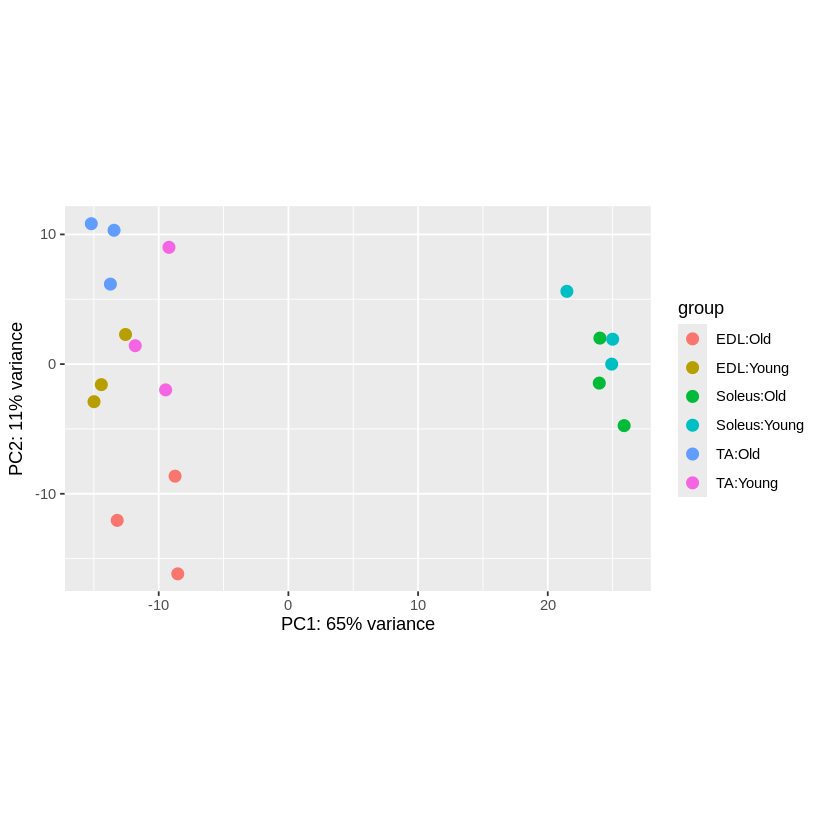

In [23]:
plotPCA(
  vsd,
  intgroup = c("muscle", "age")
)

In [24]:
png(
  "/content/drive/MyDrive/aging-muscle-transcriptomics-case-study/results/pca/PCA_plot.png",
  width = 1600,
  height = 1200,
  res = 300
)

plotPCA(
  vsd,
  intgroup = c("muscle", "age")
)

dev.off()

using ntop=500 top features by variance

ERROR while rich displaying an object: Error in grid.newpage(): could not open file '/content/drive/MyDrive/aging-muscle-transcriptomics-case-study/results/pca/PCA_plot.png'

Traceback:
1. sapply(x, f, simplify = simplify)
2. lapply(X = X, FUN = FUN, ...)
3. FUN(X[[i]], ...)
4. tryCatch(withCallingHandlers({
 .     if (!mime %in% names(repr::mime2repr)) 
 .         stop("No repr_* for mimetype ", mime, " in repr::mime2repr")
 .     rpr <- repr::mime2repr[[mime]](obj)
 .     if (is.null(rpr)) 
 .         return(NULL)
 .     prepare_content(is.raw(rpr), rpr)
 . }, error = error_handler), error = outer_handler)
5. tryCatchList(expr, classes, parentenv, handlers)
6. tryCatchOne(expr, names, parentenv, handlers[[1L]])
7. doTryCatch(return(expr), name, parentenv, handler)
8. withCallingHandlers({
 .     if (!mime %in% names(repr::mime2repr)) 
 .         stop("No repr_* for mimetype ", mime, " in repr::mime2repr")
 .     rpr <- repr::mime2repr[[mime]](

agg_record_8697df983a0 
                     2

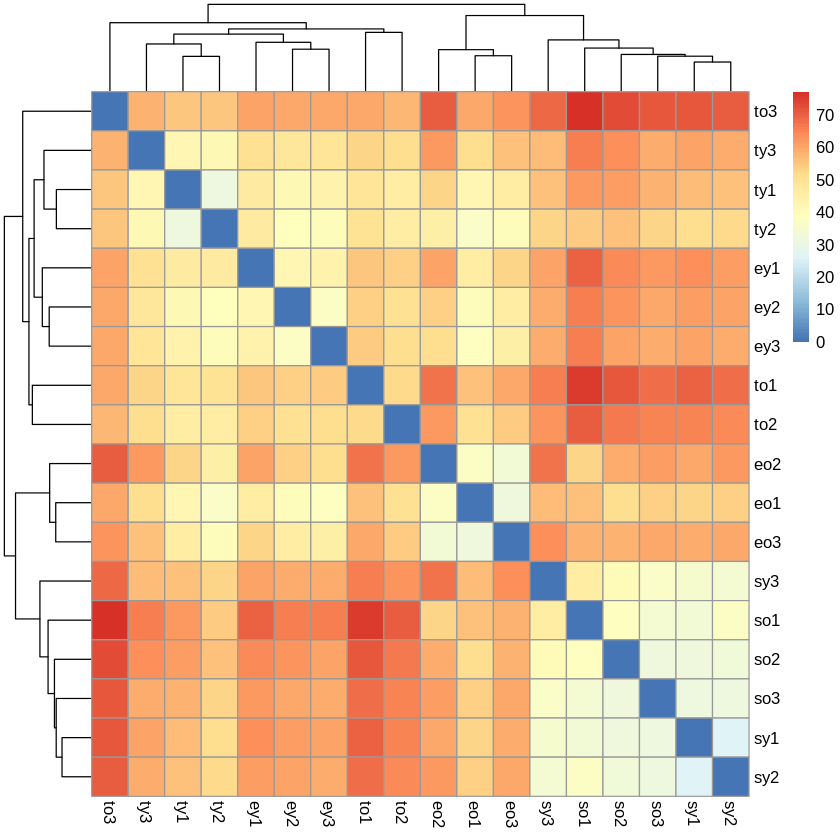

In [25]:
sampleDists <- dist(t(assay(vsd)))

sampleDistMatrix <- as.matrix(sampleDists)

rownames(sampleDistMatrix) <- metadata$sample_id
colnames(sampleDistMatrix) <- metadata$sample_id

pheatmap(
  sampleDistMatrix,
  clustering_distance_rows = sampleDists,
  clustering_distance_cols = sampleDists
)

png 
  3

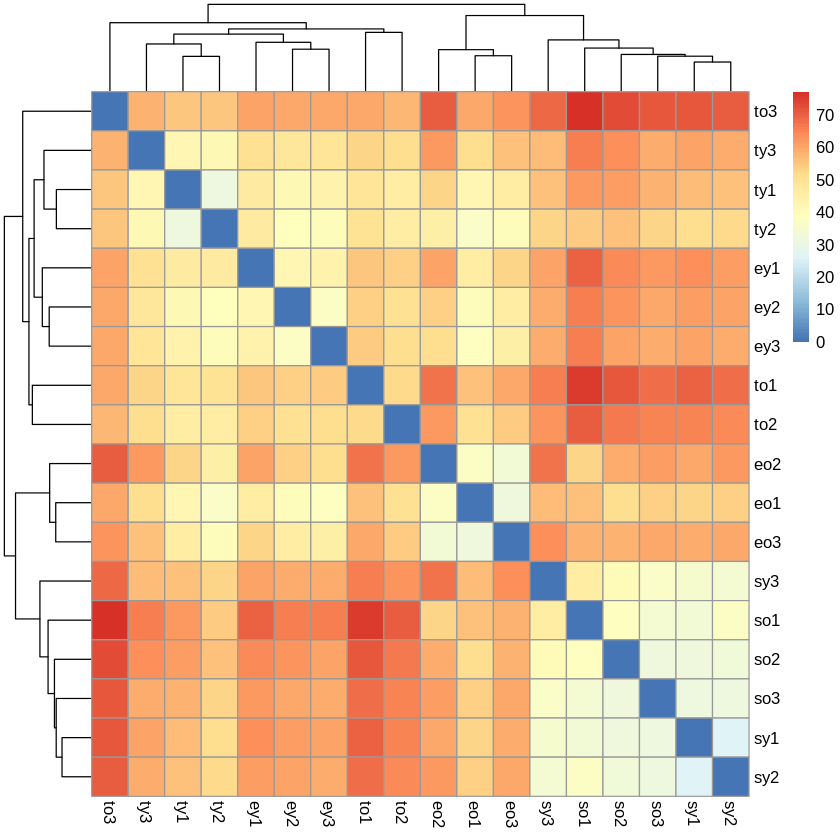

In [26]:
png(
  "/content/drive/MyDrive/aging-muscle-transcriptomics-case-study/results/pca/sample_distance_heatmap.png",
  width = 1800,
  height = 1600,
  res = 300
)

pheatmap(
  sampleDistMatrix,
  clustering_distance_rows = sampleDists,
  clustering_distance_cols = sampleDists
)

dev.off()

In [28]:
all(metadata$sample_id == names(files))
dim(dds)

[1] TRUE

[1] 11442    18